In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import cv2
from PIL import Image
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

CFG = {
    'data_dir'  : r'D:\ScanO-assign-Apaar\dataset',
    'img_size'  : 224,
    'batch_size': 32,
    'model_path': 'outputs/best_model.pth',
    'device'    : 'cpu',
}

os.makedirs('outputs/sample_outputs', exist_ok=True)
CLASS_NAMES = ['normal', 'pneumonia']
print('Config ready.')

Config ready.


In [2]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class ChestCNN(nn.Module):
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()
        self.block1 = ConvBlock(3,   32)
        self.block2 = ConvBlock(32,  64)
        self.block3 = ConvBlock(64, 128)
        self.block4 = ConvBlock(128, 256)  # Grad-CAM hooks here
        self.gap        = nn.AdaptiveAvgPool2d(1)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        return self.classifier(x)


model = ChestCNN(num_classes=2)
model.load_state_dict(torch.load(CFG['model_path'], map_location='cpu'))
model.eval()
print('Model loaded from', CFG['model_path'])

Model loaded from outputs/best_model.pth


In [3]:
test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize([0.485]*3, [0.229]*3),
])

test_dataset = datasets.ImageFolder(os.path.join(CFG['data_dir'], 'test'), transform=test_transforms)
test_loader  = DataLoader(test_dataset, batch_size=CFG['batch_size'], shuffle=False, num_workers=0)
print(f'Test samples: {len(test_dataset)}')

Test samples: 160


In [4]:
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = model(imgs)
        probs   = torch.softmax(outputs, dim=1)[:, 1]   # prob of pneumonia
        preds   = outputs.argmax(dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

acc       = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall    = recall_score(all_labels, all_preds)
f1        = f1_score(all_labels, all_preds)
auc       = roc_auc_score(all_labels, all_probs)

print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1-Score  : {f1:.4f}')
print(f'ROC-AUC   : {auc:.4f}')
print()
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

Accuracy  : 0.9062
Precision : 0.9333
Recall    : 0.8750
F1-Score  : 0.9032
ROC-AUC   : 0.9684

              precision    recall  f1-score   support

      normal       0.88      0.94      0.91        80
   pneumonia       0.93      0.88      0.90        80

    accuracy                           0.91       160
   macro avg       0.91      0.91      0.91       160
weighted avg       0.91      0.91      0.91       160



In [5]:
# ── Save metrics.txt ────────────────────────────────────
metrics_str = (
    f'Accuracy  : {acc:.4f}\n'
    f'Precision : {precision:.4f}\n'
    f'Recall    : {recall:.4f}\n'
    f'F1-Score  : {f1:.4f}\n'
    f'ROC-AUC   : {auc:.4f}\n\n'
    + classification_report(all_labels, all_preds, target_names=CLASS_NAMES)
)
with open('outputs/metrics.txt', 'w') as f:
    f.write(metrics_str)
print('Saved → outputs/metrics.txt')

Saved → outputs/metrics.txt


In [6]:
# ── Save predictions.csv ────────────────────────────────
img_paths = [s[0] for s in test_dataset.samples]
df = pd.DataFrame({
    'image_path'      : img_paths,
    'true_label'      : [CLASS_NAMES[l] for l in all_labels],
    'predicted_label' : [CLASS_NAMES[p] for p in all_preds],
    'prob_pneumonia'  : np.round(all_probs, 4),
    'correct'         : all_labels == all_preds,
})
df.to_csv('outputs/predictions.csv', index=False)
print('Saved → outputs/predictions.csv')
df.head()

Saved → outputs/predictions.csv


,image_path,true_label,predicted_label,prob_pneumonia,correct
0,D:\ScanO-assign-Apaar\dataset\test\normal\IM-0...,normal,normal,0.1464,True
1,D:\ScanO-assign-Apaar\dataset\test\normal\IM-0...,normal,normal,0.0713,True
2,D:\ScanO-assign-Apaar\dataset\test\normal\IM-0...,normal,normal,0.4546,True
3,D:\ScanO-assign-Apaar\dataset\test\normal\IM-0...,normal,normal,0.1373,True
4,D:\ScanO-assign-Apaar\dataset\test\normal\IM-0...,normal,normal,0.1828,True


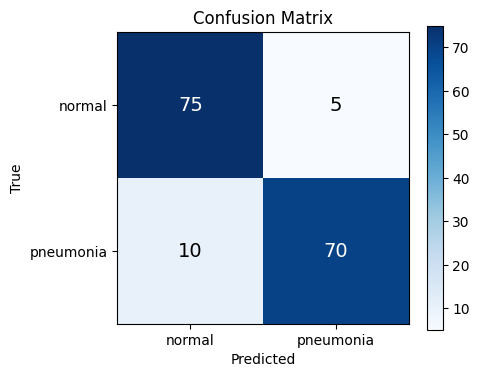

Saved → outputs/sample_outputs/confusion_matrix.png


In [7]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(CLASS_NAMES); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14,
                color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.savefig('outputs/sample_outputs/confusion_matrix.png', dpi=150)
plt.show()
print('Saved → outputs/sample_outputs/confusion_matrix.png')

In [8]:
class GradCAM:
    def __init__(self, model):
        self.model       = model
        self.activations = None
        self.gradients   = None
        # Hook block4 output — spatial maps (B, 256, 14, 14) BEFORE GAP
        model.block4.register_forward_hook(self._save_activation)
        model.block4.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, _, __, output):
        self.activations = output.detach()

    def _save_gradient(self, _, __, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.requires_grad_(True)
        out = self.model(input_tensor)
        if class_idx is None:
            class_idx = out.argmax(1).item()
        self.model.zero_grad()
        out[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2,3), keepdim=True)  # (1, 256, 1, 1)
        cam     = torch.relu((weights * self.activations).sum(1)).squeeze().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        else:
            cam = np.zeros_like(cam)
        return cam, class_idx


def save_gradcam_overlay(img_path, cam, save_path, img_size=224):
    orig    = np.array(Image.open(img_path).convert('RGB').resize((img_size, img_size)))
    cam_r   = cv2.resize(cam, (img_size, img_size))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_r), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = np.uint8(0.5 * orig + 0.5 * heatmap)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, img, title in zip(axes, [orig, cam_r, overlay], ['Original', 'Grad-CAM', 'Overlay']):
        ax.imshow(img, cmap='jet' if title=='Grad-CAM' else None, vmin=0, vmax=1 if title=='Grad-CAM' else None)
        ax.set_title(title); ax.axis('off')
    plt.colorbar(plt.cm.ScalarMappable(cmap='jet'), ax=axes[1], fraction=0.046)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()


gradcam = GradCAM(model)

# Pick 2 correct + 2 incorrect predictions for visual interest
correct_idx   = np.where(all_labels == all_preds)[0][:2]
incorrect_idx = np.where(all_labels != all_preds)[0][:2]
sample_indices = list(correct_idx) + list(incorrect_idx)

for idx in sample_indices:
    img_path  = test_dataset.samples[idx][0]
    true_cls  = CLASS_NAMES[all_labels[idx]]
    pred_cls  = CLASS_NAMES[all_preds[idx]]
    status    = 'correct' if all_labels[idx] == all_preds[idx] else 'wrong'
    tensor    = test_transforms(Image.open(img_path).convert('RGB')).unsqueeze(0)
    cam, _    = gradcam.generate(tensor)
    fname     = f'test_gradcam_{status}_true{true_cls}_pred{pred_cls}_{idx}.png'
    save_gradcam_overlay(img_path, cam, f'outputs/sample_outputs/{fname}')
    print(f'Saved: {fname}')

Saved: test_gradcam_correct_truenormal_prednormal_0.png
Saved: test_gradcam_correct_truenormal_prednormal_1.png
Saved: test_gradcam_wrong_truenormal_predpneumonia_52.png
Saved: test_gradcam_wrong_truenormal_predpneumonia_53.png


In [9]:
print('='*50)
print('EVALUATION SUMMARY')
print('='*50)
print(f'Test samples   : {len(test_dataset)}')
print(f'Accuracy       : {acc:.4f}')
print(f'F1-Score       : {f1:.4f}')
print(f'ROC-AUC        : {auc:.4f}')
print()
print('Output files:')
for f in ['outputs/metrics.txt', 'outputs/predictions.csv']:
    print(f'  {f}')
for f in os.listdir('outputs/sample_outputs'):
    print(f'  outputs/sample_outputs/{f}')

EVALUATION SUMMARY
Test samples   : 160
Accuracy       : 0.9062
F1-Score       : 0.9032
ROC-AUC        : 0.9684

Output files:
  outputs/metrics.txt
  outputs/predictions.csv
  outputs/sample_outputs/1
  outputs/sample_outputs/confusion_matrix.png
  outputs/sample_outputs/gradcam_normal_prednormal_IM-0115-0001.jpeg
  outputs/sample_outputs/gradcam_normal_prednormal_IM-0177-0001.jpeg
  outputs/sample_outputs/gradcam_pneumonia_predpneumonia_person1031_bacteria_2963.jpeg
  outputs/sample_outputs/gradcam_pneumonia_predpneumonia_person1134_bacteria_3076.jpeg
  outputs/sample_outputs/test_gradcam_correct_truenormal_prednormal_0.png
  outputs/sample_outputs/test_gradcam_correct_truenormal_prednormal_1.png
  outputs/sample_outputs/test_gradcam_wrong_truenormal_predpneumonia_52.png
  outputs/sample_outputs/test_gradcam_wrong_truenormal_predpneumonia_53.png
  outputs/sample_outputs/training_curves.png
